In [5]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42	
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

DATA_PATH = '/root/workspace/vllm-dynamic/examples/logs/'
BASELINE_DATA_PATH = f'{DATA_PATH}dllm_org_128'
linestyles = ['-', '--', '-.', ':']
markers = ['o', 's', 'D', '^', 'v', 'x', '+', '*', 'p', 'h']
hatches = ['////', '\\\\\\\\', '||||', '----', '++++', 'xx', 'oo', 'OO', '.', '**']
scheduling_policy = 'fcfs'
wt = 1.0

In [20]:
def get_res(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layer, DATA_DIR):
    output_tokens, reqs, mean_tpot, p99_tpot,  mean_ttft, p99_ttft, mean_itl, p99_itl = [], [], [], [], [], [], [], []

    filename = f'{DATA_DIR}/{model_name}_client_{gpu_utilization}_{req_rate}_{total_reqs}_recompute_{store_cache_layer}_{scheduling_policy}_wt{wt}.log'
    with open(filename, 'r') as f:
        lines = f.readlines()
        output_tokens_tgt, reqs_tgt, mean_tpot_, p99_tpot_, mean_ttft_, p99_ttft_, mean_itl_, p99_itl_ = [], [], [], [], [], [], [], []
        for line in lines:
            if 'Output token throughput' in line:
                output_tokens_tgt.append(float(line.split()[-1]))
            if 'Request throughput' in line:
                reqs_tgt.append(float(line.split()[-1]))
            if 'Mean TPOT' in line:
                mean_tpot_.append(float(line.split()[-1]))
            if 'P99 TPOT' in line:
                p99_tpot_.append(float(line.split()[-1]))
            if 'Mean TTFT' in line:
                mean_ttft_.append(float(line.split()[-1]))
            if 'P99 TTFT' in line:
                p99_ttft_.append(float(line.split()[-1]))    
            if 'Mean ITL' in line:
                mean_itl_.append(float(line.split()[-1]))
            if 'P99 ITL' in line:
                p99_itl_.append(float(line.split()[-1]))    

    output_tokens.append(np.mean(output_tokens_tgt))
    reqs.append(np.mean(reqs_tgt))
    mean_tpot.append(np.mean(mean_tpot_))
    p99_tpot.append(np.mean(p99_tpot_))
    mean_ttft.append(np.mean(mean_ttft_))
    p99_ttft.append(np.mean(p99_ttft_))
    mean_itl.append(np.mean(mean_itl_))
    p99_itl.append(np.mean(p99_itl_))

    return output_tokens, reqs, mean_tpot, p99_tpot, mean_ttft, p99_ttft, mean_itl, p99_itl 

In [7]:
# plot throughput
def get_norm_res(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layer, DATA_DIR):
    output_tokens, reqs, mean_tpot, p99_tpot, mean_ttft, p99_ttft, mean_itl, p99_itl = get_res(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layer, DATA_DIR)
    baseline_output_tokens, baseline_reqs, baseline_mean_tpot, baseline_p99_tpot, baseline_mean_ttft, baseline_p99_ttft, baseline_mean_itl, baseline_p99_itl = get_res(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layer, BASELINE_DATA_PATH)
    # 计算增长百分比
    output_tokens_imp = [(output_tokens[i]-baseline_output_tokens) / baseline_output_tokens * 100 for i in range(len(output_tokens))]
    reqs_imp = [(reqs[i]-baseline_reqs) / baseline_reqs * 100 for i in range(len(reqs))]
    mean_tpot_imp = [(baseline_mean_tpot-mean_tpot[i]) / baseline_mean_tpot *100 for i in range(len(mean_tpot))]
    p99_tpot_imp = [(baseline_p99_tpot-p99_tpot[i]) / baseline_p99_tpot *100 for i in range(len(p99_tpot))]
    mean_ttft_imp = [(baseline_mean_ttft-mean_ttft[i]) / baseline_mean_ttft *100 for i in range(len(mean_ttft))]
    p99_ttft_imp = [(baseline_p99_ttft-p99_ttft[i]) / baseline_p99_ttft *100 for i in range(len(p99_ttft))]
    mean_itl_imp = [(baseline_mean_itl-mean_itl[i]) / baseline_mean_itl *100 for i in range(len(mean_itl))]
    p99_itl_imp = [(baseline_p99_itl-p99_itl[i]) / baseline_p99_itl *100 for i in range(len(p99_itl))]

    return output_tokens_imp, reqs_imp, mean_tpot_imp, p99_tpot_imp, mean_ttft_imp, p99_ttft_imp, mean_itl_imp, p99_itl_imp
    

In [32]:
# 绘制柱状图，对比swap和recompute的性能提升
def plot_bar(rate1, rate2, store_cache_layer, req_rate):
    print('rate1:', rate1)
    print('rate2:', rate2)
    fig = plt.figure(figsize=(6, 2.5), dpi=120)
    ax = fig.add_subplot(111)
    bar_width = 0.25
    ax.bar(np.arange(8), rate1, bar_width, label='0.5:0.5', color='skyblue', hatch=hatches[0])
    ax.bar(np.arange(8)+bar_width, rate2, bar_width, label='0.25:0.75', color='lightcoral', hatch=hatches[1])
    # bar3 = ax.bar(np.arange(8)+bar_width*2, rate3, bar_width, label='0.25:0.75', color='lightgreen', hatch=hatches[2])
    # 将数值标注在柱状图上
    for x, y in zip(np.arange(8), rate1):
        if y >= 0: ax.text(x, y, f'{y:.2f}', ha='center', va='bottom', rotation=20, fontsize=8)
        else: ax.text(x, y, f'{y:.2f}', ha='center', va='top', rotation=70, fontsize=8)
    for x, y in zip(np.arange(8)+bar_width, rate2):
        if y >= 0: ax.text(x, y, f'{y:.2f}', ha='center', va='bottom', rotation=20, fontsize=8)
        else: ax.text(x, y, f'{y:.2f}', ha='center', va='top', rotation=70, fontsize=8)
    # for x, y in zip(np.arange(8)+bar_width*2, rate3):
    #     if y >= 0: ax.text(x, y, f'{y:.0f}', ha='center', va='bottom', rotation=0, fontsize=8)
    #     else: ax.text(x, y, f'{y:.0f}', ha='center', va='top', rotation=0, fontsize=8)
    ax.set_xticks(np.arange(8)+bar_width)
    ax.set_xticklabels(['out_toks', 'reqs', 'avg_tpot', 'p99_tpot', 'avg_ttft', 'p99_ttft', 'avg_itl', 'p99_itl'], rotation=0)
    ax.set_ylabel('Improvement(%)')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.yaxis.set_major_locator(plt.MultipleLocator(30))
    # ax.set_ylim(min(min(rate1), min(rate2), min(rate3))*1.4, max(max(rate1), max(rate2), max(rate3))*1.4)
    ax.set_ylim(min(min(rate1), min(rate2))*1.4, max(max(rate1), max(rate2))*1.4)

    ax.grid(linestyle='-.', alpha=0.3, axis='y')
    ax.title.set_text(f'req_rate={req_rate},cache_layer={store_cache_layer}')
    # ax.legend(bbox_to_anchor=(0.01, 1.05), loc='upper left', ncol=1, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    ax.legend(loc='best', ncol=1, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    plt.show()    

rate1: [2.2236708457771748, 3.2692307692307936, -4.51516563585528, -3.155126763628428, 2.9505986229019716, 1.8746405856518655, -0.02749950893731818, -5.314858753792618]
rate2: [-0.3767263465882452, 0.769230769230787, -4.727611624163329, -2.9331090638714348, 2.90030551946499, 1.8858904118937914, -1.5222942447456267, -4.778478658057699]


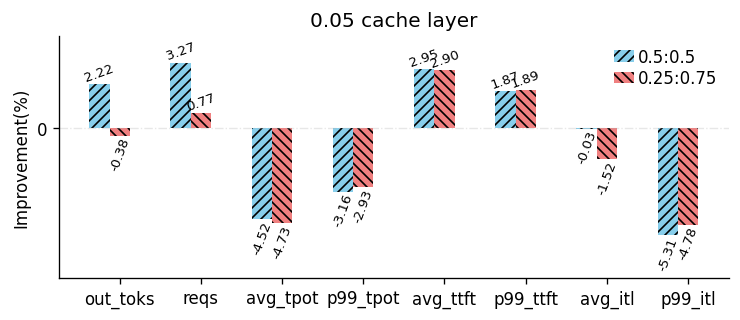

rate1: [-12.334825853641853, 9.188118811881179, -4.054893544925728, 2.9419912947178406, -2.260811067817412, -0.4944467363098103, 25.205968941726432, 21.170716163466906]
rate2: [-20.121680281641993, 0.0, -11.91744633321412, -3.761170928108411, -9.547805303067209, -8.680471089227503, 19.735038317189936, 12.130964709631144]


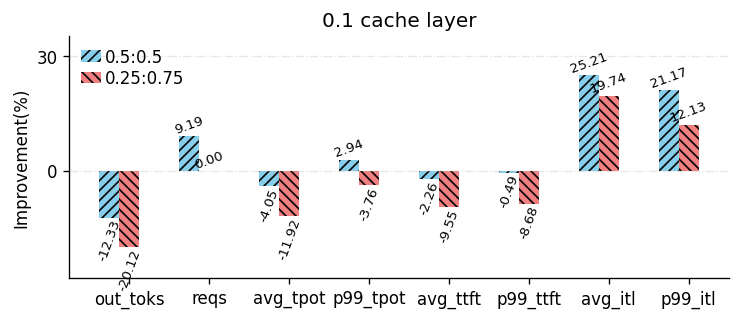

rate1: [-11.068260425440405, 0.7228915662650609, -16.082031920370707, -12.444027032375853, -20.95274880780661, -16.582302356696278, -8.106842787275845, -16.47277468686024]
rate2: [-8.524936829089077, 3.6144578313253044, -6.738524903961658, 0.337494832769082, -3.405527402136622, -1.2719109292942055, -1.818333821009068, -6.456903824936727]


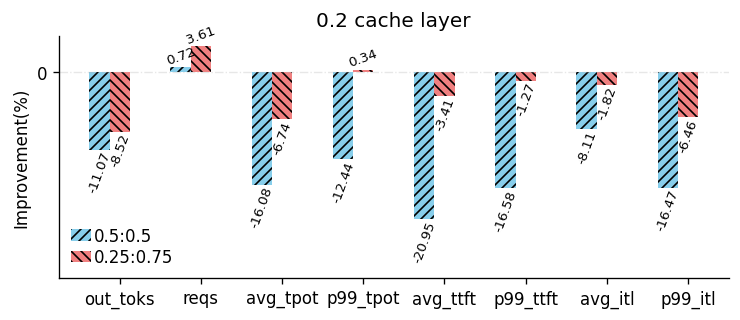

rate1: [32.462069052642256, 6.744186046511621, 5.21279574408512, -29.524615523353003, 0.3875515030153232, 13.933584192573326, 0.4667484040079539, 37.46992796822418]
rate2: [29.78132066652351, 4.457364341085271, 2.2749545009100016, -35.45509409879506, -5.312107931088394, 9.327461196164574, -2.0716188221367413, 36.4970404182217]


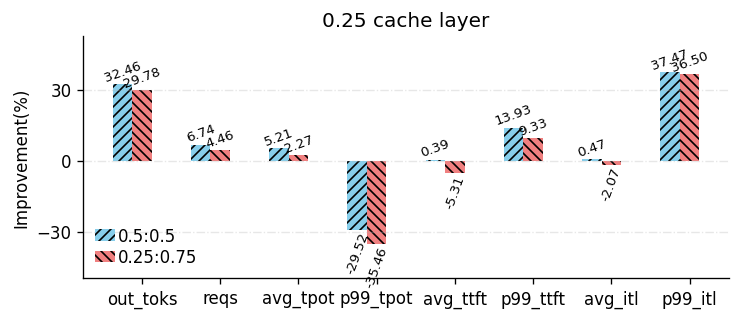

rate1: [78.42904769211454, 29.44543828264757, 29.110895389225266, -9.825367453792325, -90.64624189312302, -211.87868034027025, 32.66875882629843, 25.050658081621062]
rate2: [76.59194576573812, 29.159212880143105, 31.728325094128945, -4.618317667921296, -78.04346461827437, -195.2274784149525, 34.8611329044406, 29.858678155477698]


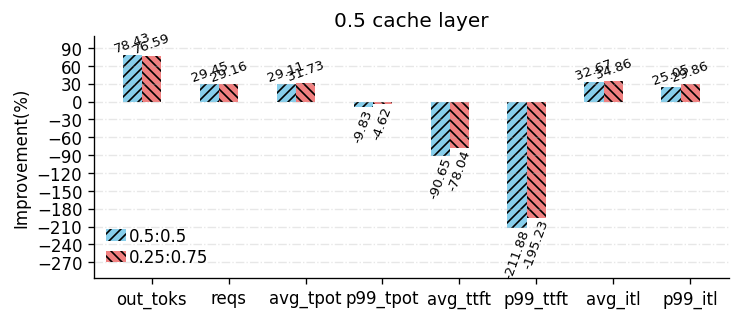

In [20]:
model_name = 'meta-llama_Llama-2-13b-hf'
gpu_utilization = 0.7
rates = ['0.5:0.5', '0.75:0.25']
num_threads = [64, 32]
store_cache_layers = [0.05, 0.1, 0.2, 0.25, 0.5]
# store_cache_layers = [0.05]
for store_cache_layer in store_cache_layers:
    output_tokens_imps, reqs_imps, mean_tpot_imps, p99_tpot_imps, mean_ttft_imps, p99_ttft_imps, mean_itl_imps, p99_itl_imps = [], [], [], [], [], [], [], []
    rate_values = []
    for i in range(len(num_threads)):
        DATA_DIR = f'{DATA_PATH}dllm_org_128_hfusion_{num_threads[i]}'
        output_tokens_imp, reqs_imp, mean_tpot_imp, p99_tpot_imp, mean_ttft_imp, p99_ttft_imp, mean_itl_imp, p99_itl_imp = get_norm_res(model_name, gpu_utilization, 300, 300, store_cache_layer, DATA_DIR)
        output_tokens_imps.append(np.mean(output_tokens_imp))
        reqs_imps.append(np.mean(reqs_imp))
        mean_tpot_imps.append(np.mean(mean_tpot_imp))
        p99_tpot_imps.append(np.mean(p99_tpot_imp))
        mean_ttft_imps.append(np.mean(mean_ttft_imp))
        p99_ttft_imps.append(np.mean(p99_ttft_imp))
        mean_itl_imps.append(np.mean(mean_itl_imp))
        p99_itl_imps.append(np.mean(p99_itl_imp))
        rate_values.append([np.mean(output_tokens_imp), np.mean(reqs_imp), np.mean(mean_tpot_imp), np.mean(p99_tpot_imp), np.mean(mean_ttft_imp), np.mean(p99_ttft_imp), np.mean(mean_itl_imp), np.mean(p99_itl_imp)])
    plot_bar(rate_values[0], rate_values[1], store_cache_layer)    


rate1: [0.10087590912160929, 0.0, 2.8024631301685923, 4.308807271833951, 3.8559419182269696, 5.457204213428683, 0.13186426771377163, -2.454896437850576]
rate2: [1.275359708180403, 1.1752136752136644, 1.8651448097481138, 2.0083527822135037, 0.9115876958349055, 2.1501471934474976, 2.270995721737088, 2.379622659835344]


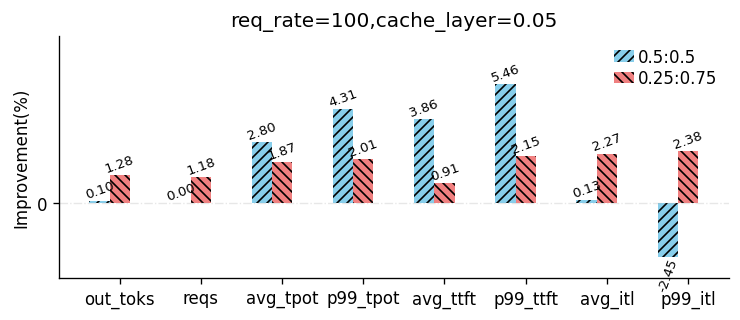

rate1: [-2.3472553101355893, -2.455357142857157, -0.5042016806722697, 4.39334251513987, 2.222198372378245, 3.580200188861455, -3.070393677740355, 0.5863874345549736]
rate2: [-1.6687696155019842, -1.7299107142857342, -0.5016160310278209, 2.0129929313592503, 1.271597795363798, 1.9037479228177274, -2.3913361627396252, -2.5454545454545516]


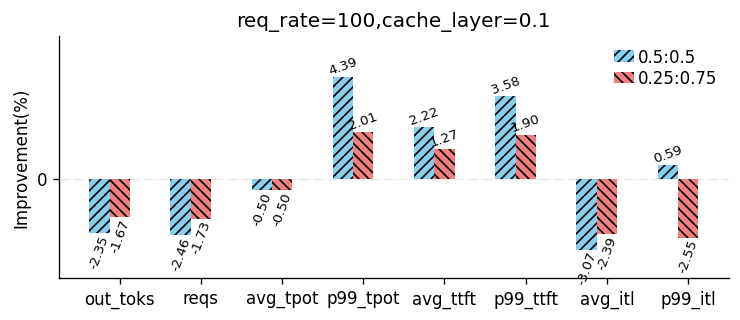

rate1: [-1.7285111351038769, -1.629072681704262, -1.9189999268952442, 0.34263864864640126, -1.1162483487450647, -1.1816095570438954, -2.2877640494220537, -2.4599685670683056]
rate2: [-0.7113448395212291, -0.5012531328320946, -1.125813290445216, -0.434919347496837, -1.6321198228300453, -1.385586414864902, -0.7227314999335493, -5.944924037081764]


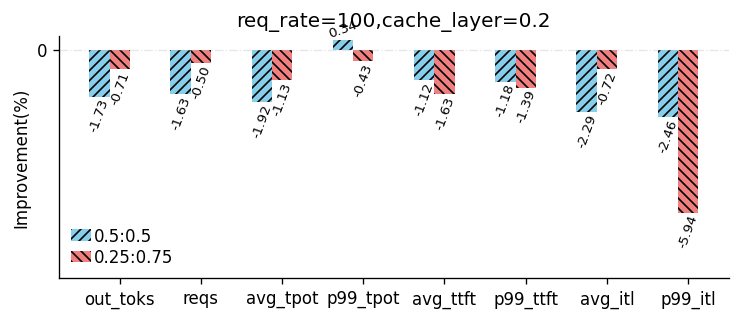

rate1: [-1.6812458916923785, -1.4616321559074312, -2.8070558018948017, -2.5638460942169017, -2.229295704534797, -2.5083231151938308, -3.245066802324014, -5.42308216378251]
rate2: [-1.71006724983567, -1.5834348355663705, -3.653291657580387, -4.236359953689237, -5.026038924362677, -5.413799143727805, -2.578382286004963, -4.177453785711012]


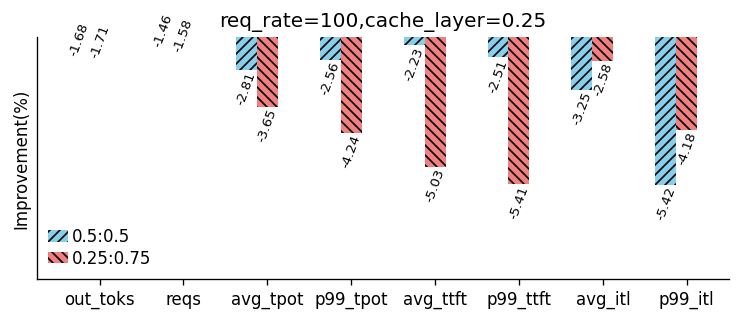

rate1: [-0.5264282522970456, -1.8567639257294302, -3.1333170474561856, -24.74365129717585, -2.6957246900539333, -3.473515172125895, -2.322862265180427, -1.067607904656077]
rate2: [-0.4315675647675007, -2.2546419098143113, -2.168378826645403, -5.18034431317409, -3.828854172457886, -3.989955103733682, -3.1699015251903018, -2.711143066721886]


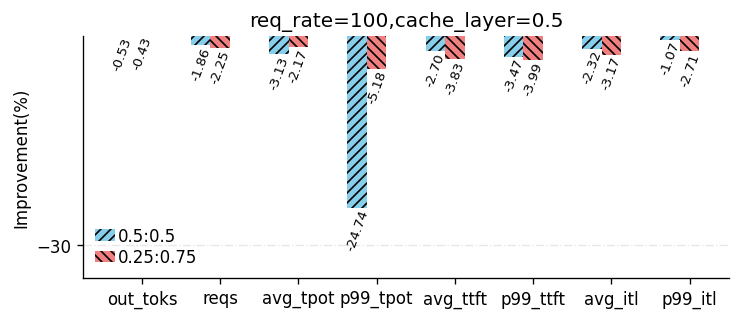

In [39]:
for store_cache_layer in store_cache_layers:
    output_tokens_imps, reqs_imps, mean_tpot_imps, p99_tpot_imps, mean_ttft_imps, p99_ttft_imps, mean_itl_imps, p99_itl_imps = [], [], [], [], [], [], [], []
    rate_values = []
    for i in range(len(num_threads)):
        DATA_DIR = f'{DATA_PATH}dllm_org_128_hfusion_{num_threads[i]}'
        output_tokens_imp, reqs_imp, mean_tpot_imp, p99_tpot_imp, mean_ttft_imp, p99_ttft_imp, mean_itl_imp, p99_itl_imp = get_norm_res(model_name, gpu_utilization, 100, 100, store_cache_layer, DATA_DIR)
        output_tokens_imps.append(np.mean(output_tokens_imp))
        reqs_imps.append(np.mean(reqs_imp))
        mean_tpot_imps.append(np.mean(mean_tpot_imp))
        p99_tpot_imps.append(np.mean(p99_tpot_imp))
        mean_ttft_imps.append(np.mean(mean_ttft_imp))
        p99_ttft_imps.append(np.mean(p99_ttft_imp))
        mean_itl_imps.append(np.mean(mean_itl_imp))
        p99_itl_imps.append(np.mean(p99_itl_imp))
        rate_values.append([np.mean(output_tokens_imp), np.mean(reqs_imp), np.mean(mean_tpot_imp), np.mean(p99_tpot_imp), np.mean(mean_ttft_imp), np.mean(p99_ttft_imp), np.mean(mean_itl_imp), np.mean(p99_itl_imp)])
    plot_bar(rate_values[0], rate_values[1], store_cache_layer, req_rate=100)    

rate1: [0.39664839589401213, 0.47255543438749187, -0.7594637165654899, 0.6066370171020897, -2.640302207096313, -2.320549494513826, -0.10286034889401019, 2.521763832304335]
rate2: [0.6032049190388196, 0.7633587786259509, 0.012571453925639353, -0.797842078965467, -0.6542105180679892, -0.6512350576617668, 0.46650804700404574, -2.387998518513219]


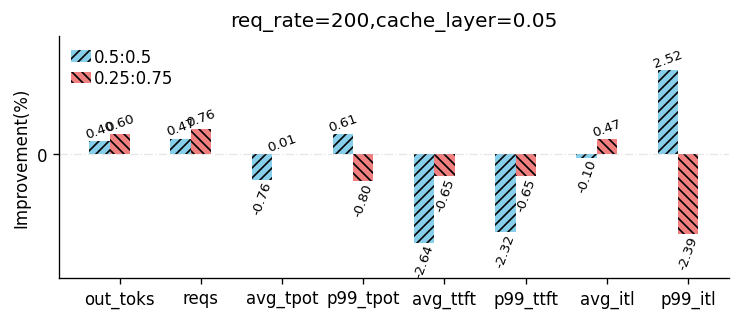

rate1: [-0.8860418338431508, -0.8876881512929251, 0.4640794567493875, 2.5420897621873557, 2.812986463728755, 2.9267782354850898, -1.2933753943217643, -4.2578706312398005]
rate2: [-0.7017987303975121, -0.656117329216498, -0.7512534111823225, -0.03208932260757795, -0.19911935372022796, 0.044548286757367314, -0.8083596214511114, -2.2893098117405772]


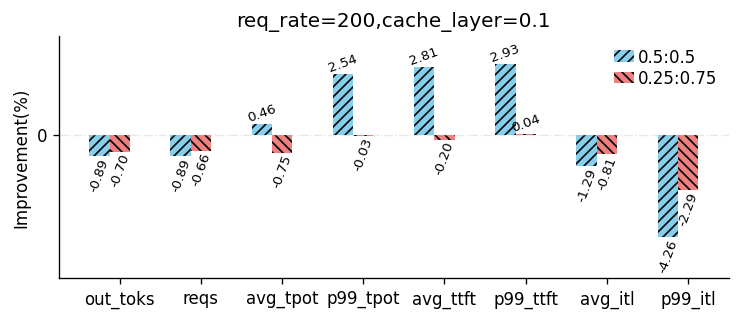

rate1: [0.17886348383060363, 0.4405286343612384, 0.03137458324094786, 0.07263680526551015, 0.860477755033441, 0.3536744412210984, -0.10689831177712995, -18.07915858035032]
rate2: [-2.5005049879780135, -2.3628354024829683, -3.988755349366466, -7.187117407490727, -2.574023338253885, -2.9804242912679024, -3.9822028756608834, -5.903072431257093]


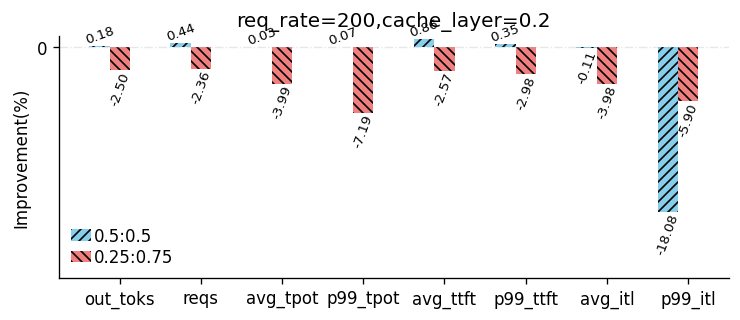

rate1: [-0.7656351478673216, -0.7751937984496282, -0.7433929930543244, -3.212761108301687, -1.5119748180125157, -1.0697695036944117, -0.53745227478737, 2.226081181739038]
rate2: [-3.1721261239835084, -3.055175558595539, -2.763430617451797, -5.740948642018138, -3.757706893703996, -5.321472004710628, -3.9306347796628858, -7.578368288327088]


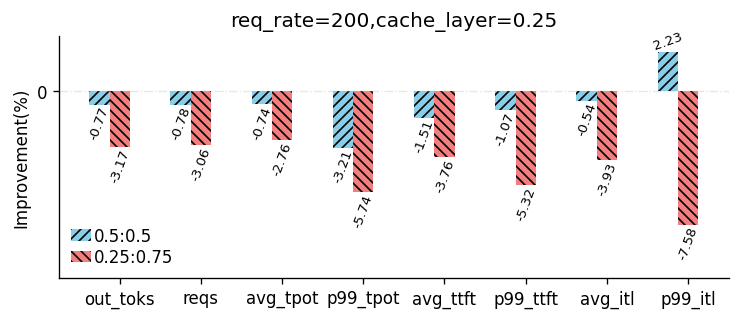

rate1: [1.0490195782814953, 0.5082592121982357, 0.8224925700064953, -19.308997518723217, 1.0293410815008803, 1.36607939726184, 1.1773500280321525, 1.7413466604018077]
rate2: [-0.11367645329464297, -0.7623888182973324, 1.3794592815787798, 5.298034840643939, 1.2623219306205167, 1.3786569450064572, 0.3102223883386577, 5.246251761992226]


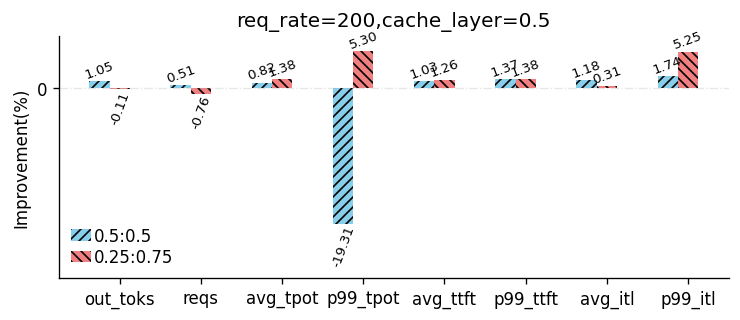

In [40]:
for store_cache_layer in store_cache_layers:
    output_tokens_imps, reqs_imps, mean_tpot_imps, p99_tpot_imps, mean_ttft_imps, p99_ttft_imps, mean_itl_imps, p99_itl_imps = [], [], [], [], [], [], [], []
    rate_values = []
    for i in range(len(num_threads)):
        DATA_DIR = f'{DATA_PATH}dllm_org_128_hfusion_{num_threads[i]}'
        output_tokens_imp, reqs_imp, mean_tpot_imp, p99_tpot_imp, mean_ttft_imp, p99_ttft_imp, mean_itl_imp, p99_itl_imp = get_norm_res(model_name, gpu_utilization, 200, 200, store_cache_layer, DATA_DIR)
        output_tokens_imps.append(np.mean(output_tokens_imp))
        reqs_imps.append(np.mean(reqs_imp))
        mean_tpot_imps.append(np.mean(mean_tpot_imp))
        p99_tpot_imps.append(np.mean(p99_tpot_imp))
        mean_ttft_imps.append(np.mean(mean_ttft_imp))
        p99_ttft_imps.append(np.mean(p99_ttft_imp))
        mean_itl_imps.append(np.mean(mean_itl_imp))
        p99_itl_imps.append(np.mean(p99_itl_imp))
        rate_values.append([np.mean(output_tokens_imp), np.mean(reqs_imp), np.mean(mean_tpot_imp), np.mean(p99_tpot_imp), np.mean(mean_ttft_imp), np.mean(p99_ttft_imp), np.mean(mean_itl_imp), np.mean(p99_itl_imp)])
    plot_bar(rate_values[0], rate_values[1], store_cache_layer, 200)    

rate1: [2.3526052531685693, 2.570735650767984, 3.1292685955544473, 1.0457250394181368, 1.1010943422373527, 1.2690642020103635, 5.023883213768159, 16.698989165304777]
rate2: [2.902981991151753, 2.894098625707361, 0.13721594436856055, -4.2698281322969605, -3.9880467104128456, -4.4200757856766275, 4.584503640624736, 18.11682101567703]


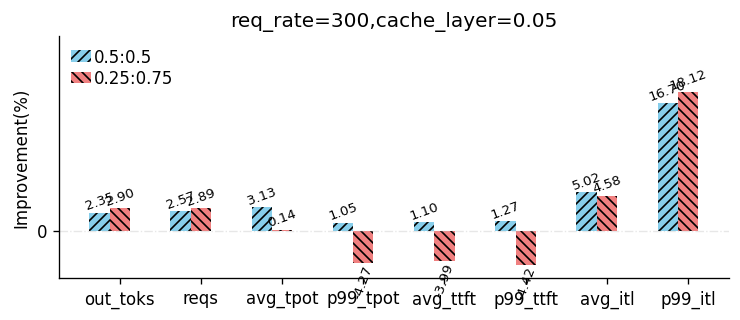

rate1: [0.24159262747893698, 0.19193857965450362, 2.8485387366221286, 5.472084361826351, 4.9710375486078, 5.948522373751248, 0.21013274592776654, -5.2760569971797056]
rate2: [-1.0289962068175385, -1.1516314779270642, -0.29011091712693016, 2.1929105082462343, 1.2898284996148761, 2.230886725423972, -1.5390412150020463, -11.298446986957654]


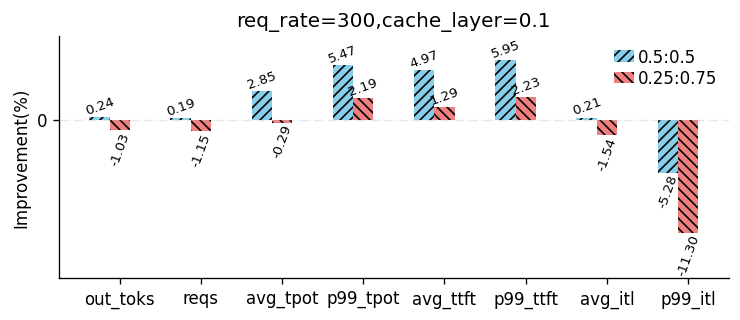

rate1: [0.7350983486262395, 0.6284367635506682, 1.7730783554900529, 0.6045477469019326, 2.309788793122254, 0.844583083935743, 1.0681912815092318, -2.768230982171599]
rate2: [0.41592799672714437, 0.3142183817753341, 1.6338228864743856, 0.7891473212444927, 0.7428810506159376, 0.646686081311301, 0.8632010505749247, 5.42556964812074]


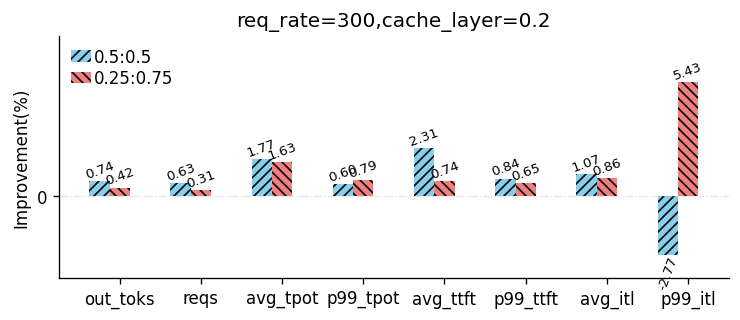

rate1: [1.0477908724127216, 1.203801478352682, 1.7761141597315642, 1.0175395598292674, 1.0013672740056352, 1.1211841420995419, 1.2903225806451613, 4.958215440858565]
rate2: [-0.09343742061047007, -0.06335797254488096, -0.50126588412011, -2.7760323101271664, -0.8531296389309861, -0.23233279460566186, 0.048904354368481805, -0.1874969215698165]


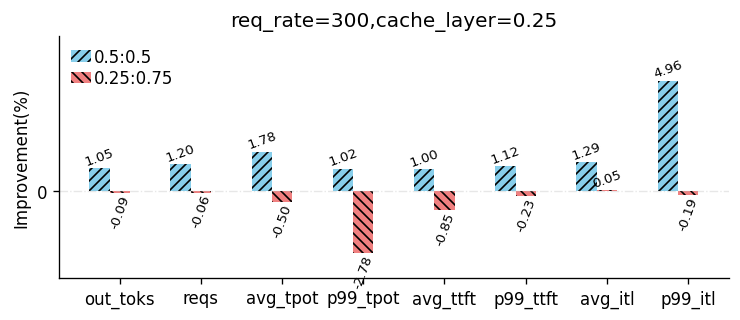

rate1: [-0.25811340413693945, 2.7244736800617345e-14, -11.85324665979033, -15.39934601999111, -0.6260239555148166, -3.386406579109601, 0.032307940830320764, 3.1351384130256994]
rate2: [-1.6599770302750794, -1.4723926380367978, -1.86320132409027, -20.68792631596967, -1.6928918635106969, -3.296622876741813, -1.4977038284909574, -3.114419413197474]


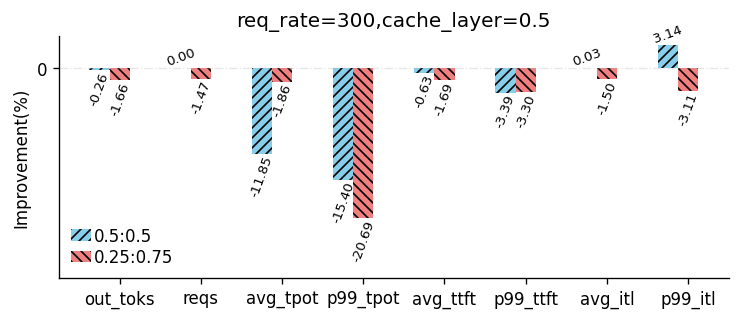

In [42]:
model_name = 'meta-llama_Llama-2-13b-hf'
gpu_utilization = 0.4
rates = ['0.5:0.5', '0.75:0.25']
num_threads = [64, 32]
store_cache_layers = [0.05, 0.1, 0.2, 0.25, 0.5]
for store_cache_layer in store_cache_layers:
    output_tokens_imps, reqs_imps, mean_tpot_imps, p99_tpot_imps, mean_ttft_imps, p99_ttft_imps, mean_itl_imps, p99_itl_imps = [], [], [], [], [], [], [], []
    rate_values = []
    for i in range(len(num_threads)):
        DATA_DIR = f'{DATA_PATH}dllm_org_128_hfusion_{num_threads[i]}'
        output_tokens_imp, reqs_imp, mean_tpot_imp, p99_tpot_imp, mean_ttft_imp, p99_ttft_imp, mean_itl_imp, p99_itl_imp = get_norm_res(model_name, gpu_utilization, 300, 300, store_cache_layer, DATA_DIR)
        output_tokens_imps.append(np.mean(output_tokens_imp))
        reqs_imps.append(np.mean(reqs_imp))
        mean_tpot_imps.append(np.mean(mean_tpot_imp))
        p99_tpot_imps.append(np.mean(p99_tpot_imp))
        mean_ttft_imps.append(np.mean(mean_ttft_imp))
        p99_ttft_imps.append(np.mean(p99_ttft_imp))
        mean_itl_imps.append(np.mean(mean_itl_imp))
        p99_itl_imps.append(np.mean(p99_itl_imp))
        rate_values.append([np.mean(output_tokens_imp), np.mean(reqs_imp), np.mean(mean_tpot_imp), np.mean(p99_tpot_imp), np.mean(mean_ttft_imp), np.mean(p99_ttft_imp), np.mean(mean_itl_imp), np.mean(p99_itl_imp)])
    plot_bar(rate_values[0], rate_values[1], store_cache_layer, req_rate=300)    

rate1: [0.5669987355384599, 0.6209386281588598, 5.5607789667131, 9.378470163333514, 9.244729876511979, 10.451033966565616, 1.2990353697749246, -9.682642283820856]
rate2: [1.82224270571133, 1.8339350180505383, 4.82757803005602, 6.547419355861596, 6.681472576375934, 7.575080427251531, 2.109324758842446, 0.29658543932424913]


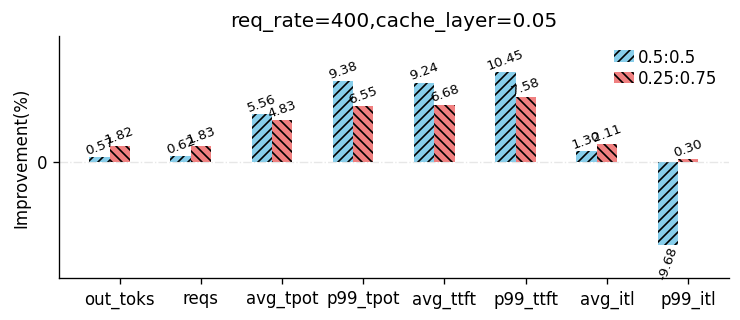

rate1: [2.4160028100386746, 2.415181138585383, 3.7330985115327793, 4.117059995473713, 3.3607749199016537, 3.8365598806815693, 2.7658998009211966, 10.965827969166318]
rate2: [1.3947181179945947, 1.35135135135133, 2.451425974321099, 2.6120486241221044, 2.0340153482909638, 2.5677746131673835, 2.1421587683028993, 6.270083059190537]


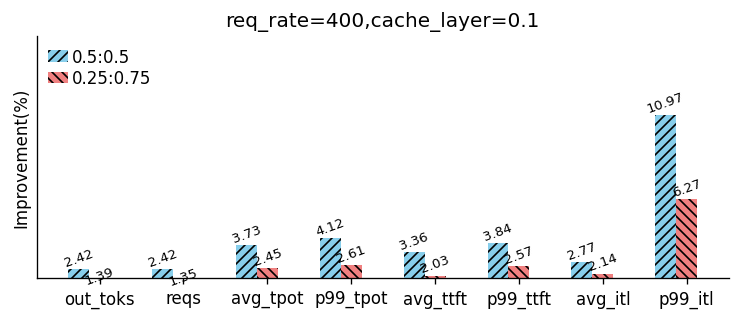

rate1: [0.5049992708736077, 0.4672897196261686, -0.9346321648864148, -7.7403938642231775, 0.2591740736239276, 0.7897632199274245, 0.5979048891350931, -6.340582260069927]
rate2: [-0.7611445382093956, -0.7009345794392616, 0.02303670828945699, 0.538399230496633, -1.7268959784828861, -1.0881484624288242, -0.6744758149916005, -5.300631055434356]


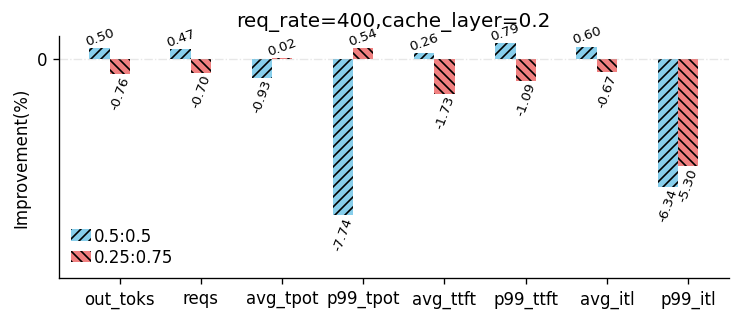

rate1: [0.9846174812190325, 1.1054421768707396, 1.0788409038581661, 2.6194910592799188, 0.9792367897711814, 1.2707211082257843, 0.9117801243166366, 4.1078640167549]
rate2: [-1.149004309830825, -1.147959183673475, -0.43964959598287967, 0.8257982958109377, -1.0637503894990246, -0.7487702338128354, -0.8481240170748201, 2.1863760482851995]


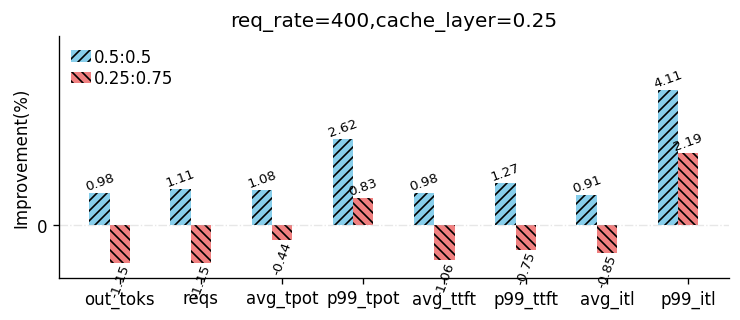

rate1: [0.8557507751365622, 0.37082818294190395, 2.305229735757964, 15.495242823290992, 1.1211496078976513, 0.46354163767129003, 0.6046969483898248, 2.3833157394423434]
rate2: [-0.17028397066784404, -0.08240626287595579, 0.7189902647668368, 15.093309585834755, 0.2783857239904141, -1.2051217929173095, -0.15390865482271152, -1.1832548173123962]


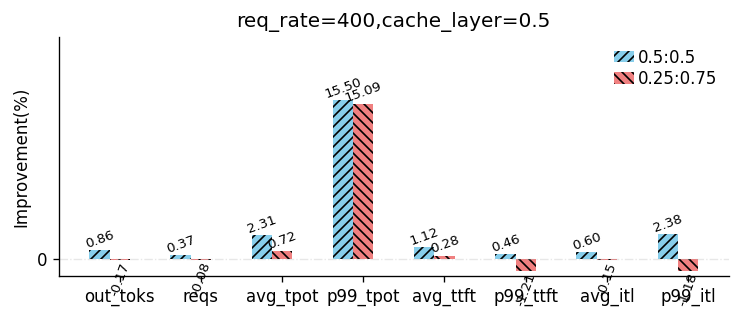

In [37]:
model_name = 'meta-llama_Llama-2-13b-hf'
gpu_utilization = 0.4
rates = ['0.5:0.5', '0.75:0.25']
num_threads = [64, 32]
store_cache_layers = [0.05, 0.1, 0.2, 0.25, 0.5]
for store_cache_layer in store_cache_layers:
    output_tokens_imps, reqs_imps, mean_tpot_imps, p99_tpot_imps, mean_ttft_imps, p99_ttft_imps, mean_itl_imps, p99_itl_imps = [], [], [], [], [], [], [], []
    rate_values = []
    for i in range(len(num_threads)):
        DATA_DIR = f'{DATA_PATH}dllm_org_128_hfusion_{num_threads[i]}'
        output_tokens_imp, reqs_imp, mean_tpot_imp, p99_tpot_imp, mean_ttft_imp, p99_ttft_imp, mean_itl_imp, p99_itl_imp = get_norm_res(model_name, gpu_utilization, 400, 400, store_cache_layer, DATA_DIR)
        output_tokens_imps.append(np.mean(output_tokens_imp))
        reqs_imps.append(np.mean(reqs_imp))
        mean_tpot_imps.append(np.mean(mean_tpot_imp))
        p99_tpot_imps.append(np.mean(p99_tpot_imp))
        mean_ttft_imps.append(np.mean(mean_ttft_imp))
        p99_ttft_imps.append(np.mean(p99_ttft_imp))
        mean_itl_imps.append(np.mean(mean_itl_imp))
        p99_itl_imps.append(np.mean(p99_itl_imp))
        rate_values.append([np.mean(output_tokens_imp), np.mean(reqs_imp), np.mean(mean_tpot_imp), np.mean(p99_tpot_imp), np.mean(mean_ttft_imp), np.mean(p99_ttft_imp), np.mean(mean_itl_imp), np.mean(p99_itl_imp)])
    plot_bar(rate_values[0], rate_values[1], store_cache_layer, req_rate=400)    

rate1: [0.021098535360480262, 1.1970059564691716e-14, 1.5812062344703128, 1.5225530003791499, -0.1081654245835104, 0.8401714335409212, 0.8067744908010824, 5.381954839326094]
rate2: [1.749246878865454, 1.8328840970350542, 4.908892402680527, 6.207937448692972, 5.040743137276387, 6.193313905132568, 3.1231927806552267, 8.200133762221737]


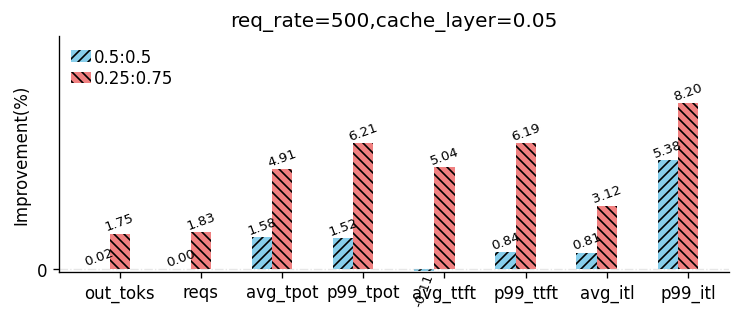

rate1: [-0.7871655729429825, -0.7945516458569689, 0.669950243755325, 1.7548782863751131, 1.3412232178294474, 1.0156750169228006, -0.29701314922451294, 4.370568669581898]
rate2: [0.9814217206317196, 1.0215664018161317, 1.4936925164597437, 2.0687473300576, 1.9673009821544487, 1.6754881032517217, 1.1408452089418626, 1.5871019036165173]


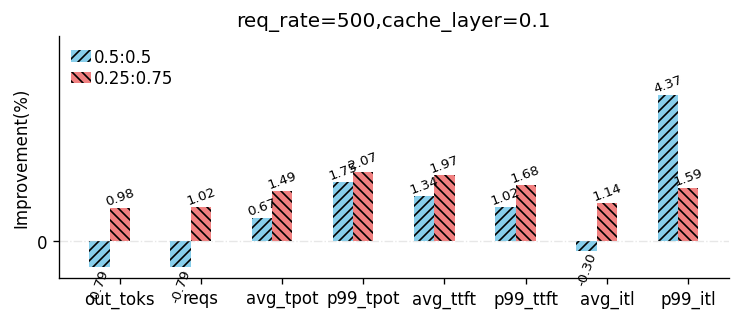

rate1: [0.694745050363654, 0.6686478454680624, 0.5577775163706256, 0.6449399947490215, 1.5187210657197494, 1.0602377852319065, 0.4056375668108862, 3.101774906707646]
rate2: [1.4607145159656225, 1.3372956909361082, 2.0399560835980113, 1.6343702624647571, 1.9011516323095647, 1.8382480044631233, 1.5573301094426164, 8.161513374517858]


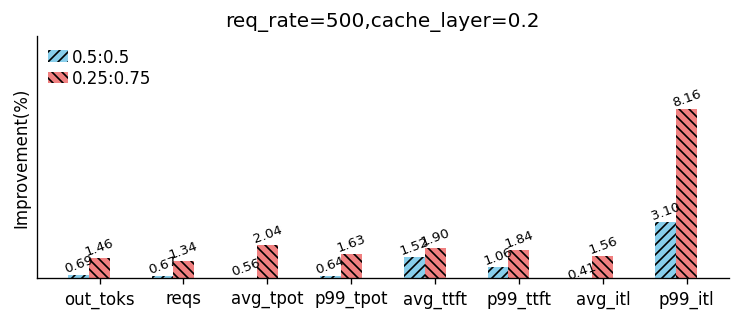

rate1: [0.6023214268281964, 0.6410256410256239, 0.23754604606325314, -0.08674545382197237, 1.1831944196923416, 1.1950178894889762, 0.8198632963168828, 2.6772855401962135]
rate2: [0.9573363791077932, 0.9615384615384446, 1.963484467701769, 2.6487870226678907, 1.9554003968670068, 1.8724835454265323, 1.3401266572182182, 6.171091881157252]


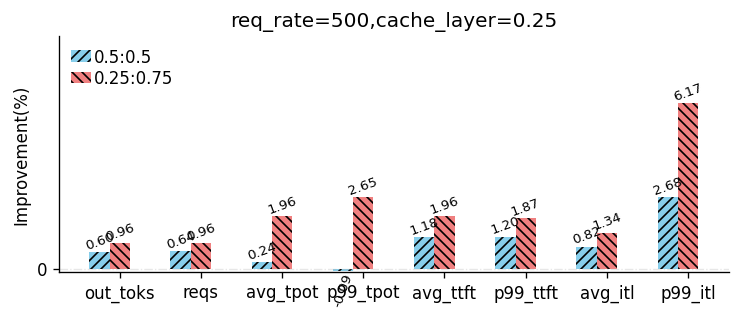

rate1: [-0.2896484364036392, 0.5834305717619479, -0.5184700185765928, 8.021443783505916, 0.40665331342319777, 0.9923708690137143, 0.3613980274662527, 3.662093276863395]
rate2: [0.13528153715752378, 0.5834305717619479, 7.858513262478314, 13.119776749651157, 0.060335800260387436, 0.9139902626119049, 0.7554384574133182, 4.25807106084046]


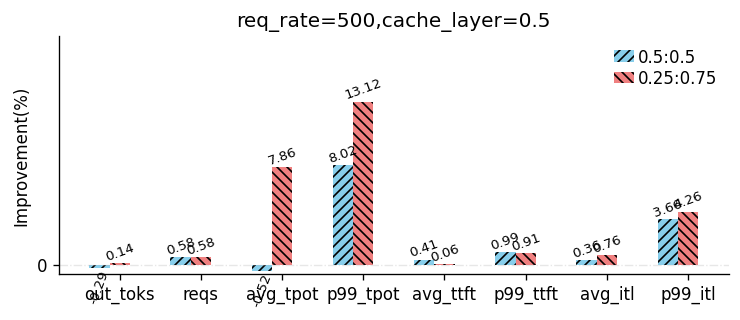

In [34]:
model_name = 'meta-llama_Llama-2-13b-hf'
gpu_utilization = 0.4
rates = ['0.5:0.5', '0.75:0.25']
num_threads = [64, 32]
store_cache_layers = [0.05, 0.1, 0.2, 0.25, 0.5]
for store_cache_layer in store_cache_layers:
    output_tokens_imps, reqs_imps, mean_tpot_imps, p99_tpot_imps, mean_ttft_imps, p99_ttft_imps, mean_itl_imps, p99_itl_imps = [], [], [], [], [], [], [], []
    rate_values = []
    for i in range(len(num_threads)):
        DATA_DIR = f'{DATA_PATH}dllm_org_128_hfusion_{num_threads[i]}'
        output_tokens_imp, reqs_imp, mean_tpot_imp, p99_tpot_imp, mean_ttft_imp, p99_ttft_imp, mean_itl_imp, p99_itl_imp = get_norm_res(model_name, gpu_utilization, 500, 500, store_cache_layer, DATA_DIR)
        output_tokens_imps.append(np.mean(output_tokens_imp))
        reqs_imps.append(np.mean(reqs_imp))
        mean_tpot_imps.append(np.mean(mean_tpot_imp))
        p99_tpot_imps.append(np.mean(p99_tpot_imp))
        mean_ttft_imps.append(np.mean(mean_ttft_imp))
        p99_ttft_imps.append(np.mean(p99_ttft_imp))
        mean_itl_imps.append(np.mean(mean_itl_imp))
        p99_itl_imps.append(np.mean(p99_itl_imp))
        rate_values.append([np.mean(output_tokens_imp), np.mean(reqs_imp), np.mean(mean_tpot_imp), np.mean(p99_tpot_imp), np.mean(mean_ttft_imp), np.mean(p99_ttft_imp), np.mean(mean_itl_imp), np.mean(p99_itl_imp)])
    plot_bar(rate_values[0], rate_values[1], store_cache_layer, req_rate=500)    